# Machine Learning–Based Employee Attrition Prediction and Risk Scoring System

## Problem Statement


#### • Palo Alto Networks faces challenges such as:
#### -● Sudden, unanticipated resignations
#### -● Loss of high-performing or critical employees
#### -● Reactive counter-offers that come too late

#### • The organization lacks:
#### - ● A systematic way to predict attrition risk
#### - ● Quantitative risk scores for employees
#### - ● Visibility into key drivers influencing exit decisions.

### Dataset Fields Description:

##### FIELD NAME             ------------------>                              DESCRIPTION

##### Age                     ------------------->                          	Age of the employee in years

##### Attrition               ------------------>        	             Indicates whether the employee left the organization (0 / 1)

##### BusinessTravel	          ----------------->                      Frequency of business travel (Non-Travel,Travel Rarely,Travel Frequently)

##### DailyRate                ---------------->                 Daily compensation rate of the employee

##### Department	          -------------------->                  Department where the employee works (e.g., R&D,Sales, HR)

##### DistanceFromHome	  -------------------->                Distance between employee’s home and workplace

##### Education	         --------------------->                       Education level (1:Below College, 2:College,3:Bachelor, 4:Master, 5:Doctor)

##### EducationField	-------------------------->                         Field of education (e.g., Life Sciences,Medical, Technical)

##### EnvironmentSatisfaction   ------------------------>            	Satisfaction with the work environment (1 = Low, 4 = High)

##### Gender	 -------------------------->                                 Gender of the employee (Male / Female)

##### HourlyRate  ------------------------->                                 	Hourly wage of the employee

##### JobInvolvement   ----------------------->               	     Level of involvement in work (1 = Low, 4 = High)

##### JobLevel	  --------------------------->                           Job seniority level (1 = Entry level, highervalues = senior roles)

##### JobRole	  ------------------------>                              Specific job role or designation of the employees 

##### JobSatisfaction ------------------------->                 	        Satisfaction with the job role (1 = Low, 4 = High)

##### MaritalStatus   ------------------------>                      	Marital status of the employee (Single,Married, Divorced)

##### MonthlyIncome    ---------------------->                     	Monthly salary earned by the employee

##### MonthlyRate	  --------------------->                         Monthly compensation rat(administrative pay metric)

##### NumCompaniesWorked  --------------------->                  	Number of companies the employee has worked for  previously

##### OverTime	    --------------------->                         Indicates whether the employee works overtime(Yes / No)

##### PercentSalaryHike	 -------------------->                      Percentage increase in salary during the appraisal

##### PerformanceRating	  -------------------->                     Performance evaluation score of the employees

##### RelationshipSatisfaction	------------------->               Satisfaction with workplace relationships (1 = Low, 4 = High)

##### StockOptionLevel	 --------------------->                       Level of stock options granted to the employee

##### TotalWorkingYears	  -------------------->                      Total professional experience across all companies (in years)

##### TrainingTimesLastYear --------------------->                   	Number of training programs attended in the last year

##### WorkLifeBalance  ------------------------->                       	Work-life balance rating (1 = Poor, 4 = Excellent)

##### YearsAtCompany  --------------------->                             	Number of years the employee has worked at Palo Alto Networks 

##### YearsInCurrent  -------------------->                         Role Number of years in the current role

##### YearsSinceLastPromotion ----------------->	                     Number of years since the last promotion

##### YearsWithCurrManager	   ----------------------->                   Number of years working with the current manager


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("C:/Users/nehau/Downloads/Palo Alto Networks.csv")

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [4]:
print(df['Attrition'].unique())

[1 0]


In [5]:
df['Attrition'] = df['Attrition'].replace({
    'Yes': 1,
    'No': 0
})

In [6]:
print(df['Attrition'].unique())
print(df['Attrition'].isnull().sum())

[1 0]
0


In [7]:
print(df.select_dtypes(include='object').columns.tolist())

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [8]:
df['Gender'] = df['Gender'].map({
    'Male': 1,
    'Female': 0
})

df['OverTime'] = df['OverTime'].map({
    'Yes': 1,
    'No': 0
})

In [9]:
df = pd.get_dummies(
    df,
    columns=[
        'BusinessTravel',
        'Department',
        'EducationField',
        'JobRole',
        'MaritalStatus'
    ],
    drop_first=True
)

In [10]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [11]:
print(df.select_dtypes(include='object').columns.tolist())

[]


In [12]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [13]:
print(y.isnull().sum())

0


### Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Scale Features

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Logistic Regression

In [16]:
class_weight='balanced'

### SMOTE

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)


y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]


In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_smote.value_counts())

Attrition
0    986
1    986
Name: count, dtype: int64


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Feature Engineering

In [20]:
df['Income_Experience_Ratio'] = (
    df['MonthlyIncome'] /
    (df['TotalWorkingYears'] + 1)
)

### Promotion Delay Indicator

In [21]:
df['Promotion_Delay'] = (
    df['YearsSinceLastPromotion'] >= 3
).astype(int)

### Engagement Score

In [22]:
df['Engagement_Score'] = (
    df['JobSatisfaction'] +
    df['EnvironmentSatisfaction'] +
    df['RelationshipSatisfaction'] +
    df['WorkLifeBalance']
) / 4

### Workload Stress Flag

In [23]:
df['Workload_Stress'] = (
    (df['OverTime'] == 1) &
    (df['JobInvolvement'] >= 3)
).astype(int)

### MODEL DEVELOPMENT

#### logistic Regression(Baseline)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    solver='lbfgs',
    random_state=42
)

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


### Random Forest

In [26]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Gradient Boosting

In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]

### Model Evaluation

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
def evaluate_model(y_true, y_pred, y_prob):

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

### Risk Scoring Framework

#### Generate employee risk scores

In [29]:
risk_prob = rf.predict_proba(X_test)[:,1]

In [30]:
risk_df = pd.DataFrame({
    'AttritionProbability': risk_prob
})

### Feature Importance

#### Random Forest 

In [31]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
10,MonthlyIncome,0.072340
0,Age,0.058383
18,TotalWorkingYears,0.058316
1,DailyRate,0.052087
11,MonthlyRate,0.048133
2,DistanceFromHome,0.047196
21,YearsAtCompany,0.046441
6,HourlyRate,0.043994
13,OverTime,0.042008
24,YearsWithCurrManager,0.040964


### SHAP Explainability

In [32]:
!pip install shap -q

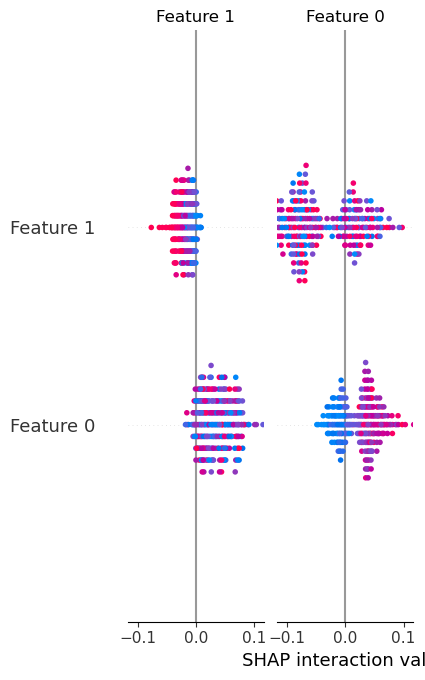

In [33]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

### Individual-level reason codes (e.g., low satisfaction + high overtime)

In [34]:
def reason_codes(row):
    reasons = []

    if row['JobSatisfaction'] <= 2:
        reasons.append("Low Job Satisfaction")

    if row['OverTime'] == 1:
        reasons.append("High Overtime")

    if row['WorkLifeBalance'] <= 2:
        reasons.append("Poor Work-Life Balance")
        
    if row['YearsSinceLastPromotion'] >= 4:
        reasons.append("Promotion Delay")
        
    if row['MonthlyIncome'] < X_test['MonthlyIncome'].median():
        reasons.append("Low Income")   

    return " + ".join(reasons[:3]) if reasons else "No major risk factors"

In [35]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.8401360544217688
Precision: 0.5
Recall   : 0.2765957446808511
ROC-AUC  : 0.793952967525196


In [36]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Income_Experience_Ratio,Promotion_Delay,Engagement_Score,Workload_Stress
0,41,1,1102,1,2,2,0,94,3,2,...,0,0,1,0,0,1,665.888889,0,2.00,1
1,49,0,279,8,1,3,1,61,2,2,...,0,1,0,0,1,0,466.363636,0,3.00,0
2,37,1,1373,2,2,4,1,92,2,1,...,0,0,0,0,0,1,261.250000,0,3.00,0
3,33,0,1392,3,4,4,0,56,3,1,...,0,1,0,0,1,0,323.222222,1,3.25,1
4,27,0,591,2,1,1,1,40,3,1,...,0,0,0,0,1,0,495.428571,0,2.50,0


#### This project predicts employee attrition and gives simple reasons for predictions. It helps companies understand employee behavior and reduce turnover.